In [2]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

load_dotenv('../.env')

# Conectar a PostgreSQL
conn = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD")
)

# Cargar datos de voto nacionalista
df = pd.read_sql("SELECT * FROM nationalist_vote", conn)
print(f"Total registros: {len(df)}")
print(df.head())

Total registros: 550
  nuts2_id region_name country_code  year  nationalist_vote_share  \
0     DE11   Stuttgart           DE  2013                5.074850   
1     DE11   Stuttgart           DE  2017               12.583165   
2     DE12   Karlsruhe           DE  2013                6.097715   
3     DE12   Karlsruhe           DE  2017               13.077316   
4     DE13    Freiburg           DE  2013                5.036574   

   nationalist_weighted_index  
0                    4.937771  
1                   12.243275  
2                    5.933007  
3                   12.724079  
4                    4.900529  


C:\Users\Guille\AppData\Local\Temp\ipykernel_20660\3516505859.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM nationalist_vote", conn)


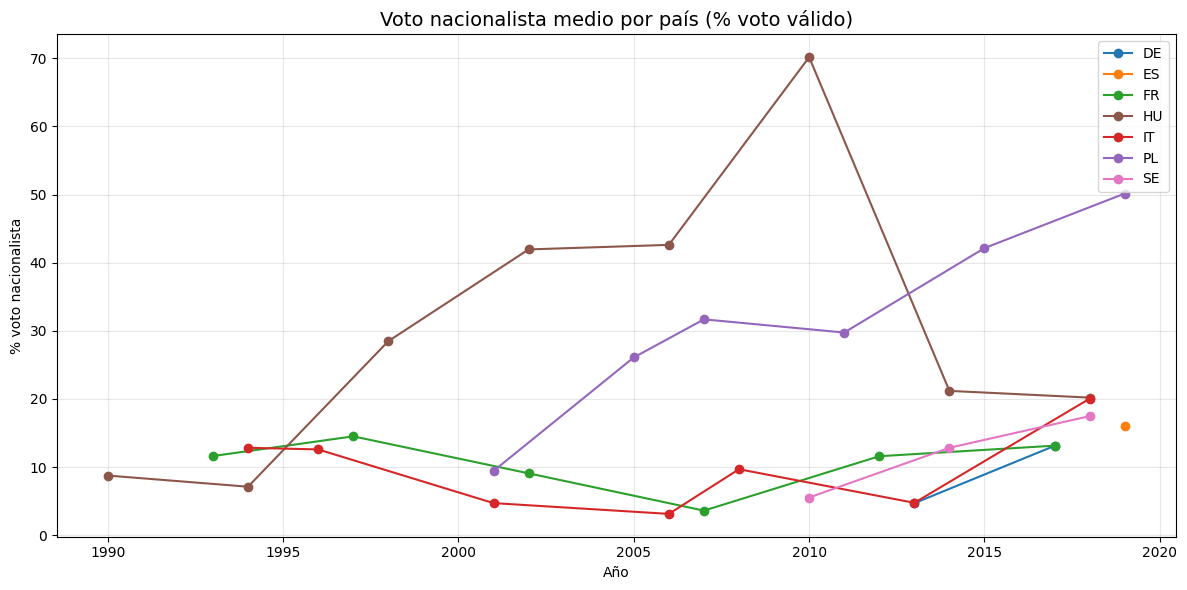

In [3]:
# Voto nacionalista medio por país y año
df_country = df.groupby(['country_code', 'year'])['nationalist_vote_share'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

countries = df_country['country_code'].unique()
colors = {'DE': '#1f77b4', 'ES': '#ff7f0e', 'FR': '#2ca02c', 
          'IT': '#d62728', 'PL': '#9467bd', 'HU': '#8c564b', 'SE': '#e377c2'}

for country in countries:
    data = df_country[df_country['country_code'] == country]
    ax.plot(data['year'], data['nationalist_vote_share'], 
            marker='o', label=country, color=colors.get(country, 'gray'))

ax.set_title('Voto nacionalista medio por país (% voto válido)', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('% voto nacionalista')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
print(df.groupby('country_code')['year'].unique())

country_code
DE                                        [2013, 2017]
ES                                              [2019]
FR                [1993, 1997, 2002, 2007, 2012, 2017]
HU    [1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018]
IT          [1994, 1996, 2001, 2006, 2008, 2013, 2018]
PL                [2001, 2005, 2007, 2011, 2015, 2019]
SE                                  [2010, 2014, 2018]
Name: year, dtype: object


In [5]:
# Primera vs última elección por país
df_first = df.groupby('country_code').apply(
    lambda x: x[x['year'] == x['year'].min()]['nationalist_vote_share'].mean()
).reset_index(name='first_election')

df_last = df.groupby('country_code').apply(
    lambda x: x[x['year'] == x['year'].max()]['nationalist_vote_share'].mean()
).reset_index(name='last_election')

df_compare = df_first.merge(df_last, on='country_code')
df_compare['change'] = df_compare['last_election'] - df_compare['first_election']
df_compare = df_compare.sort_values('change', ascending=False)
print(df_compare)

  country_code  first_election  last_election     change
5           PL        9.442474      50.146544  40.704071
6           SE        5.544829      17.483858  11.939029
3           HU        8.764435      20.200747  11.436312
0           DE        4.708550      13.129221   8.420671
4           IT       12.839192      20.050886   7.211694
2           FR       11.627909      13.150752   1.522842
1           ES       16.059990      16.059990   0.000000


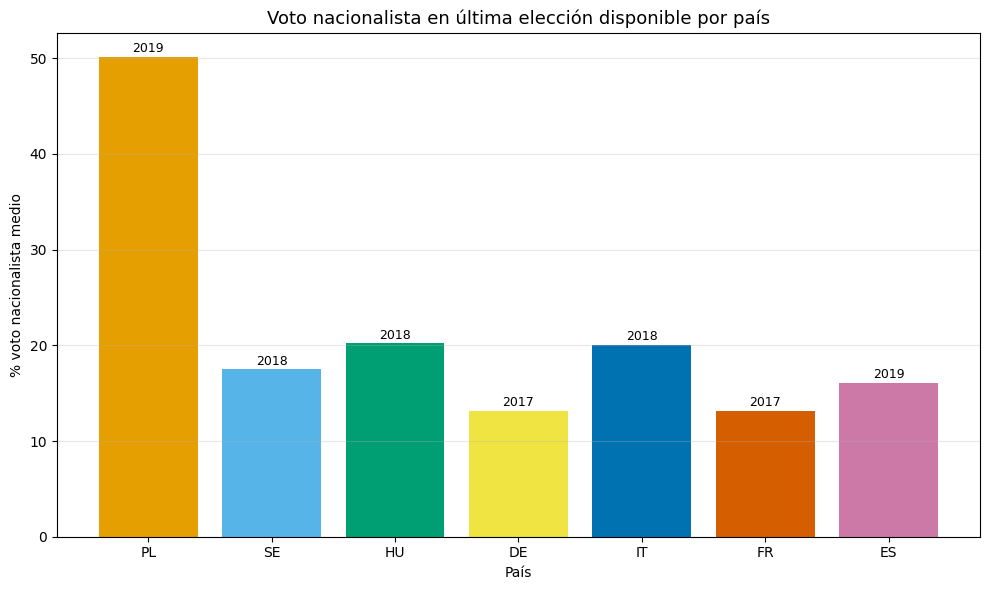

In [6]:
# Paleta Okabe-Ito apta para daltónicos
colors_cb = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(df_compare['country_code'], df_compare['last_election'], color=colors_cb)

ax.set_title('Voto nacionalista en última elección disponible por país', fontsize=13)
ax.set_xlabel('País')
ax.set_ylabel('% voto nacionalista medio')

# Añadir el año de la última elección encima de cada barra
for i, (_, row) in enumerate(df_compare.iterrows()):
    year = df[df['country_code'] == row['country_code']]['year'].max()
    ax.text(i, row['last_election'] + 0.5, str(year), ha='center', fontsize=9)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [7]:
# Ver distribución regional de Polonia en 2019
df_poland = df[(df['country_code'] == 'PL') & (df['year'] == 2019)]
print(df_poland[['nuts2_id', 'region_name', 'nationalist_vote_share']].sort_values('nationalist_vote_share', ascending=False))

    nuts2_id            region_name  nationalist_vote_share
501     PL82           Podkarpackie               70.450709
495     PL81              Lubelskie               63.659887
519     PL92  Mazowiecki regionalny               63.153499
489     PL72         Świętokrzyskie               61.125724
423     PL21            Małopolskie               59.485330
507     PL84              Podlaskie               58.991160
483     PL71                Łódzkie               52.265722
429     PL22                Śląskie               49.162967
471     PL62    Warmińsko-mazurskie               46.104312
465     PL61     Kujawsko-pomorskie               45.075479
453     PL51           Dolnośląskie               44.853649
435     PL41          Wielkopolskie               43.434515
459     PL52               Opolskie               43.345988
441     PL42     Zachodniopomorskie               42.072780
477     PL63              Pomorskie               41.625126
447     PL43               Lubuskie     

In [8]:
# Ver si hay votos desde el extranjero en otros países
abroad = df[df['nuts2_id'].str.contains('ZZ', na=False)]
print(abroad.groupby('country_code')['nuts2_id'].unique())

country_code
PL    [PLZZ]
Name: nuts2_id, dtype: object
